#  Global Layoffs Analysis (2020–2024)

This project analyzes global layoffs data using SQL to uncover trends across companies, industries, countries, and time.

##  Problem Statement

In recent years, global layoffs have increased significantly across industries.  
This project aims to analyze layoffs data to identify patterns across companies, industries, and time, and understand the impact of economic conditions on employment.

##  Objective

- Identify companies with highest layoffs  
- Analyze industry-wise impact  
- Understand geographic trends  
- Study layoffs over time  
- Derive meaningful insights  

##  Dataset

The dataset contains:
- Company  
- Industry  
- Country  
- Total Laid Off  
- Percentage Laid Off  
- Date  
- Stage  
- Funds Raised  

##  Data Import

The dataset was imported into MySQL and verified using the following query:

In [ ]:
SELECT *
FROM layoffs
LIMIT 10;

OUTPUT:

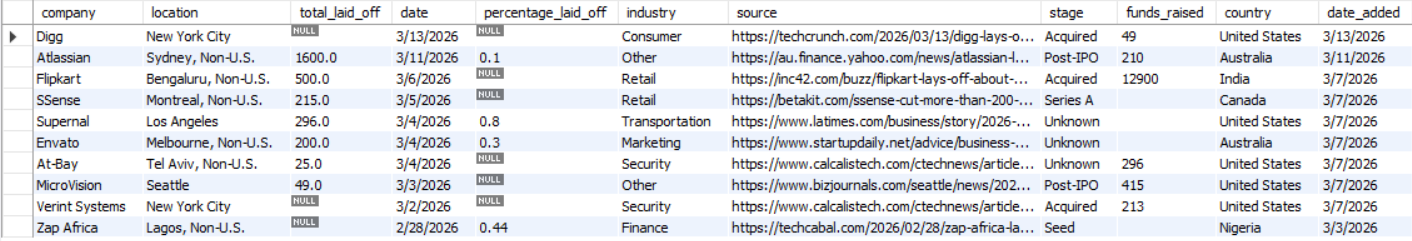

##  Data Cleaning

### Q1: Are there any null values in key columns?

In [ ]:
SELECT *
FROM layoffs
WHERE total_laid_off IS NULL
   OR percentage_laid_off IS NULL;



**Explanation:**  
This query checks for missing values in key columns such as `total_laid_off` and `percentage_laid_off`.

**Observation:**  
No blank values were found in the dataset. However, NULL values may exist and are handled separately.

**Action Taken:**  
No action was required for blank values as none were present.

### Q2: Are there duplicate records in the dataset?

In [ ]:
SELECT company, location, industry, total_laid_off, percentage_laid_off, date, stage, country, funds_raised_millions,
COUNT(*) AS duplicate_count
FROM layoffs
GROUP BY company, location, industry, total_laid_off, percentage_laid_off, date, stage, country, funds_raised_millions
HAVING COUNT(*) > 1;

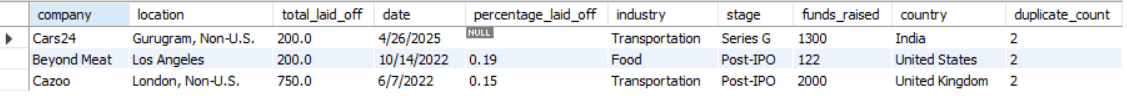

**Explanation:**  
This query identifies duplicate rows based on all columns.

### Q3: How were duplicates removed?

In [ ]:
CREATE TABLE layoffs_cleaned AS
SELECT *
FROM (
    SELECT *,
    ROW_NUMBER() OVER(
        PARTITION BY company, location, industry, total_laid_off, percentage_laid_off, date, stage, country, funds_raised_millions
    ) AS row_num
    FROM layoffs
) ranked_data
WHERE row_num = 1;

**Explanation:**  
Duplicates were removed using ROW_NUMBER(), keeping only the first occurrence of each record.


**Insight:**  
Duplicate records can inflate results and lead to incorrect analysis, making their removal critical for data accuracy.

### Q4: Were there inconsistencies in categorical data?

In [ ]:
SELECT DISTINCT company FROM layoffs_cleaned;

**Explanation:**  
This checks for inconsistencies such as extra spaces or different formats.

### Q5: How were inconsistencies handled?

In [ ]:
UPDATE layoffs_cleaned
SET company = TRIM(company);



**Explanation:**  
Standardization ensures consistent grouping during analysis.

### Q6: Are there NULL values in important columns?

In [ ]:
SELECT *
FROM layoffs_cleaned
WHERE total_laid_off IS NULL
AND percentage_laid_off IS NULL;

**Explanation:**  
Identifies rows where critical data is missing.

### Q7: How were NULL values handled?

In [ ]:
DELETE
FROM layoffs_cleaned
WHERE total_laid_off IS NULL
AND percentage_laid_off IS NULL;

**Explanation:**  
Rows with no layoff data were removed as they do not contribute to analysis.

##  Exploratory Data Analysis

### Q1: What is the total number of layoffs?

In [ ]:
SELECT SUM(total_laid_off) AS total_layoffs
FROM layoffs_cleaned;

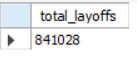

**Insight:**  
Represents the overall impact of layoffs across industries.

### Q2: Top 10 companies with highest layoffs?

In [ ]:
SELECT company, SUM(total_laid_off) AS total_laid_off
FROM layoffs_cleaned
GROUP BY company
ORDER BY total_laid_off DESC;

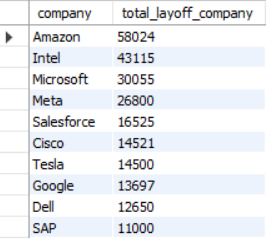

**Insight:**  
Layoffs are concentrated among a few large companies, indicating disproportionate impact.

### Q3: Which industries were most affected?

In [ ]:
SELECT industry, SUM(total_laid_off) AS total_laid_off
FROM layoffs_cleaned
GROUP BY industry
ORDER BY total_laid_off DESC;

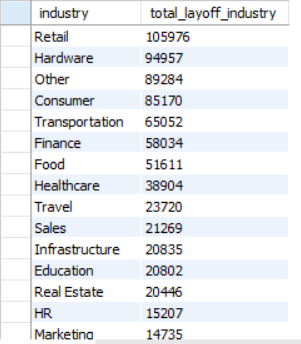

**Insight:**  
Tech-related industries show higher layoffs due to rapid scaling and correction cycles.

### Q4: Which countries had the most layoffs?

In [ ]:
SELECT country, SUM(total_laid_off) AS total_laid_off
FROM layoffs_cleaned
GROUP BY country
ORDER BY total_laid_off DESC;

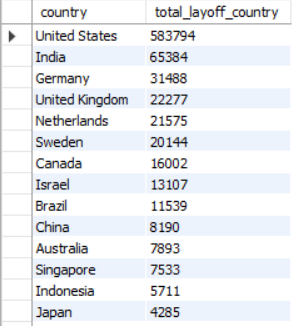

**Insight:**  
Countries with strong startup ecosystems dominate layoffs.

### Q5: How did layoffs change over time?

In [ ]:
SELECT YEAR(date) AS year, SUM(total_laid_off) AS total_laid_off
FROM layoffs_cleaned
GROUP BY YEAR(date)
ORDER BY year;

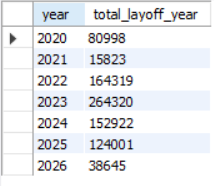

**Insight:**  
Layoffs peaked during economic downturn periods.

### Q6: What is the monthly trend of layoffs?

In [ ]:
SELECT DATE_FORMAT(date, '%Y-%m') AS month,
SUM(total_laid_off) AS total_laid_off
FROM layoffs_cleaned
GROUP BY month
ORDER BY month;

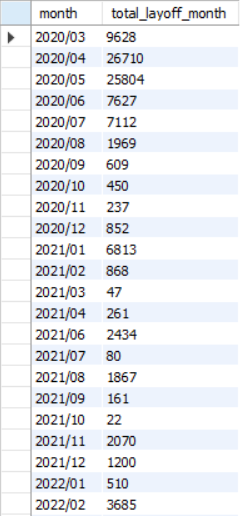

**Insight:**  
Layoffs occur in waves, indicating periodic economic shocks.

### Q7: Which stage companies had the most layoffs?

In [ ]:
SELECT stage, SUM(total_laid_off) AS total_laid_off
FROM layoffs_cleaned
GROUP BY stage
ORDER BY total_laid_off DESC;

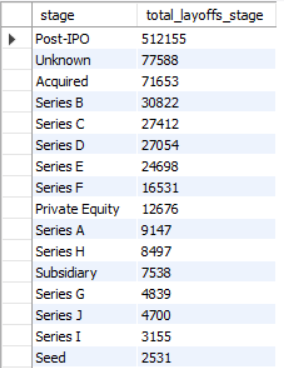

**Insight:**  
Late-stage companies face higher layoffs due to larger workforce sizes.

### Q: Which companies had the highest layoffs each year?

In [ ]:
SELECT *
FROM (
    SELECT company,
           YEAR(date) AS year,
           SUM(total_laid_off) AS total_laid_off,
           RANK() OVER (
               PARTITION BY YEAR(date)
               ORDER BY SUM(total_laid_off) DESC
           ) AS ranking
    FROM layoffs_cleaned
    GROUP BY company, YEAR(date)
) ranked_data
WHERE ranking <= 5;

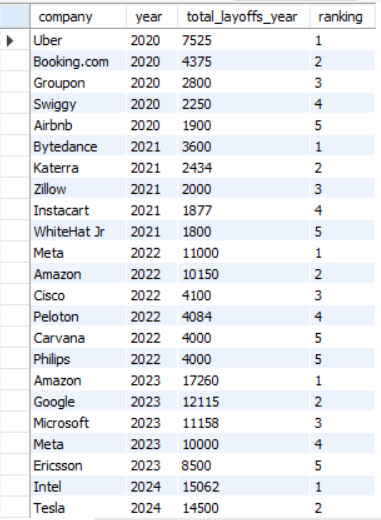

**Insight:**  
Top companies contributing to layoffs vary each year, reflecting changing economic conditions.

### Q: What is the cumulative layoffs trend?

In [ ]:
SELECT month,
       SUM(total_laid_off) AS monthly_layoffs,
       SUM(SUM(total_laid_off)) OVER (ORDER BY month) AS rolling_total
FROM (
    SELECT DATE_FORMAT(date, '%Y-%m') AS month,
           total_laid_off
    FROM layoffs_cleaned
) t
GROUP BY month
ORDER BY month;

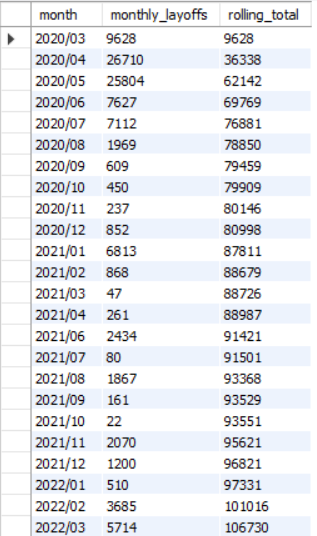

**Insight:**  
Cumulative layoffs show sustained economic stress over time.

### Q: Which companies had complete layoffs (100%)?

In [ ]:
SELECT company, percentage_laid_off
FROM layoffs_cleaned
WHERE percentage_laid_off = 1;

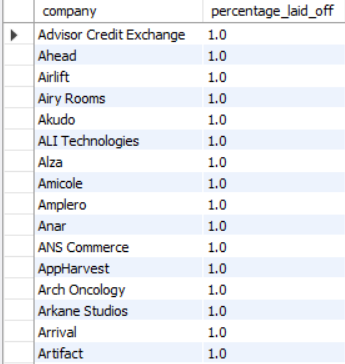

##  Key Insights

- Layoffs are concentrated in major companies  
- Tech industry is most affected  
- US dominates layoffs  
- Layoffs peaked during economic downturn  
- Late-stage companies faced higher layoffs  
- Layoffs occurred in waves  

##  Conclusion

This analysis highlights how economic conditions and funding cycles influence workforce reductions. It provides insights into industry trends and employment risks.